# LLM Training Pipeline — Part 3: Reward Model & PPO

Stage 3 of 6. Builds a preference dataset by sampling and sentiment-scoring SFT
completions, trains a reward model on it, then runs a full from-scratch PPO
loop (rollout, GAE, clipped surrogate objective, KL penalty) against
`sft_model.pt` to produce `ppo_model.pt`. This is the heaviest notebook in the
series — expect more moving parts than notebooks 1-2.

**How to use this notebook:**
- Read each theory section; keep `docs/llm_training_pipeline_reference.html`
  open in another tab (Sections 5-6) for the full derivations.
- Code and tests are already implemented and verified — run cells top to
  bottom. Answer the **Question** cells yourself.

**Parts:**
1. Preference Dataset Construction
2. Reward Model
3. PPO Core (rollout, GAE, clipped objective)
4. PPO Training Loop

In [1]:
import time, math, os, json, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tokenizers import ByteLevelBPETokenizer
from transformers import pipeline as hf_pipeline

import sys
sys.path.insert(0, '../..')
from src.llm_pipeline.model import GPTConfig, GPTModel, Block
from src.llm_pipeline.data import TOPIC_KEYWORDS, format_sft_prompt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

CKPT_DIR = "../../data/checkpoints/llm_training_pipeline"
torch.manual_seed(0)

tokenizer = ByteLevelBPETokenizer(
    f"{CKPT_DIR}/tinystories_bpe-vocab.json",
    f"{CKPT_DIR}/tinystories_bpe-merges.txt",
)
EOT_ID = tokenizer.token_to_id('<|endoftext|>')

sft_ckpt = torch.load(f"{CKPT_DIR}/sft_model.pt", weights_only=False)
sft_cfg = sft_ckpt['config']
sft_model = GPTModel(sft_cfg).to(device)
sft_model.load_state_dict(sft_ckpt['model_state_dict'])
sft_model.eval()
BLOCK_SIZE = sft_cfg.block_size
print(f"Loaded sft_model.pt — {sum(p.numel() for p in sft_model.parameters()):,} params")

Device: cuda


Loaded sft_model.pt — 13,817,856 params


---
## Part 1: Preference Dataset Construction

For each topic, sample a *group* of completions from `sft_model` at temperature, score
each with a sentiment classifier (a cheap, automatable stand-in for a human preference
judgment), and pair the highest- and lowest-scoring completions as `(chosen, rejected)`.
Groups where the best and worst score are indistinguishable are dropped (no clear
preference). See `docs/llm_training_pipeline_reference.html#s5` for why a reward model
needs pairwise, not absolute, preference data.

In [2]:
sentiment_pipe = hf_pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if device == 'cuda' else -1,
)

def sentiment_score(text):
    """Signed scalar in [-1, 1]: +confidence for POSITIVE, -confidence for NEGATIVE."""
    result = sentiment_pipe(text[:512])[0]
    sign = 1.0 if result['label'] == 'POSITIVE' else -1.0
    return sign * result['score']

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [3]:
# TEST 1: sentiment scorer sanity
pos_score = sentiment_score("I am so happy today, everything is wonderful and bright!")
neg_score = sentiment_score("This is terrible, I am so sad and scared and everything is awful.")
assert pos_score > 0, f"expected positive score, got {pos_score}"
assert neg_score < 0, f"expected negative score, got {neg_score}"
print(f"TEST 1 PASSED — sentiment scorer sane (pos={pos_score:.3f}, neg={neg_score:.3f})")

TEST 1 PASSED — sentiment scorer sane (pos=1.000, neg=-1.000)


In [4]:
N_PROMPTS_PER_TOPIC = 5
GROUP_SIZE = 6
MAX_NEW_TOKENS = 40

@torch.no_grad()
def sample_group(topic, group_size, max_new_tokens):
    prompt = format_sft_prompt(topic)
    prompt_ids = torch.tensor([tokenizer.encode(prompt).ids], device=device)
    prompt_batch = prompt_ids.repeat(group_size, 1)
    out = sft_model.generate(prompt_batch, max_new_tokens=max_new_tokens, temperature=1.0, top_k=40)
    completions = [tokenizer.decode(out[i, prompt_ids.shape[1]:].tolist()) for i in range(group_size)]
    return prompt, completions

preference_pairs = []
t0 = time.time()
for topic in TOPIC_KEYWORDS:
    for _ in range(N_PROMPTS_PER_TOPIC):
        prompt, completions = sample_group(topic, GROUP_SIZE, MAX_NEW_TOKENS)
        scores = [sentiment_score(c) for c in completions]
        best_i = max(range(GROUP_SIZE), key=lambda i: scores[i])
        worst_i = min(range(GROUP_SIZE), key=lambda i: scores[i])
        if abs(scores[best_i] - scores[worst_i]) < 1e-3:
            continue  # tie — no clear preference, drop
        preference_pairs.append({
            'prompt': prompt,
            'chosen': completions[best_i],
            'rejected': completions[worst_i],
            'chosen_score': scores[best_i],
            'rejected_score': scores[worst_i],
        })
print(f"Built {len(preference_pairs)} preference pairs in {time.time()-t0:.0f}s "
      f"from {len(TOPIC_KEYWORDS) * N_PROMPTS_PER_TOPIC} prompt instances")

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Built 199 preference pairs in 135s from 200 prompt instances


In [5]:
# TEST 2: pair construction sanity
assert len(preference_pairs) > 100, f"expected >100 pairs, got {len(preference_pairs)}"
for p in preference_pairs[:5]:
    assert p['chosen_score'] > p['rejected_score']
print(f"TEST 2 PASSED — {len(preference_pairs)} pairs, chosen_score > rejected_score verified on samples")

TEST 2 PASSED — 199 pairs, chosen_score > rejected_score verified on samples


### Question 1

The rejected completion in each pair is the *lowest-sentiment* completion sampled in that
group — not necessarily a *bad* completion by any other standard (grammar, topicality,
coherence). Given this construction, what does the reward model in Part 2 actually learn to
prefer? Is that the same thing as "prefer better stories"?

*Write your answer below:*

In [6]:
with open(f"{CKPT_DIR}/preference_pairs.json", 'w') as f:
    json.dump(preference_pairs, f, indent=2)
print(f"Saved {len(preference_pairs)} preference pairs to {CKPT_DIR}/preference_pairs.json")

Saved 199 preference pairs to ../../data/checkpoints/llm_training_pipeline/preference_pairs.json


---
## Part 2: Reward Model

The reward model shares the GPT trunk architecture with the policy but replaces the tied LM
head with a single scalar head applied to the hidden state at the completion's last real
token (not necessarily the last position in the padded tensor — see the length-aware
gather below). Its trunk is initialized from `sft_model`'s weights. See
`docs/llm_training_pipeline_reference.html#s5` for the Bradley-Terry derivation.

In [7]:
class RewardModel(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config
        self.tok_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.drop = nn.Dropout(config.dropout)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.reward_head = nn.Linear(config.n_embd, 1, bias=False)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, lengths=None):
        """idx: (B, T) padded token ids. lengths: (B,) real (unpadded) sequence
        lengths, or None to use position T-1 for every example (only correct when
        every sequence in the batch fills the full T with no trailing padding)."""
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device).unsqueeze(0)
        x = self.tok_emb(idx) + self.pos_emb(pos)
        x = self.drop(x)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        if lengths is None:
            last = x[:, -1, :]
        else:
            last_idx = (lengths - 1).clamp(min=0)
            last = x[torch.arange(B, device=x.device), last_idx, :]
        return self.reward_head(last).squeeze(-1)


def load_trunk_from_sft(reward_model, sft_state_dict):
    """Copies token/position embeddings, transformer blocks, and final LayerNorm
    from an SFT GPTModel's state dict into a freshly-initialized RewardModel,
    leaving reward_head randomly initialized."""
    trunk_keys = [k for k in sft_state_dict if k.startswith(('tok_emb', 'pos_emb', 'blocks', 'ln_f'))]
    own_state = reward_model.state_dict()
    for k in trunk_keys:
        own_state[k].copy_(sft_state_dict[k])


def bradley_terry_loss(reward_chosen, reward_rejected):
    return -F.logsigmoid(reward_chosen - reward_rejected).mean()


def encode_pair_text(prompt, completion, block_size):
    """Returns (padded_ids: LongTensor[block_size], real_length: int)."""
    ids = (tokenizer.encode(prompt).ids + tokenizer.encode(completion).ids + [EOT_ID])[:block_size]
    length = len(ids)
    ids = ids + [EOT_ID] * (block_size - length)
    return torch.tensor(ids, dtype=torch.long), length

In [8]:
# TEST 3: trunk transplant, Bradley-Terry loss sanity, and length-aware gather correctness
rm_cfg = sft_cfg
reward_model = RewardModel(rm_cfg).to(device)
load_trunk_from_sft(reward_model, sft_model.state_dict())
assert torch.allclose(reward_model.tok_emb.weight, sft_model.tok_emb.weight)
assert torch.allclose(reward_model.blocks[0].attn.qkv_proj.weight, sft_model.blocks[0].attn.qkv_proj.weight)
print("TEST 3a PASSED — trunk weights transplanted correctly from sft_model")

rc = torch.tensor([2.0, 0.0])
rr = torch.tensor([0.0, 2.0])
loss = bradley_terry_loss(rc, rr)
expected = -(torch.log(torch.sigmoid(torch.tensor(2.0))) + torch.log(torch.sigmoid(torch.tensor(-2.0)))) / 2
assert torch.allclose(loss, expected, atol=1e-5), f"{loss.item()} != {expected.item()}"
print(f"TEST 3b PASSED — Bradley-Terry loss matches hand-computed value ({loss.item():.4f})")

reward_model.eval()
ids_short, len_short = encode_pair_text("dog", "A dog ran fast.", 64)
ids_long, len_long = encode_pair_text("dog", "A dog ran fast.", 256)
with torch.no_grad():
    r_short = reward_model(ids_short.unsqueeze(0).to(device), torch.tensor([len_short], device=device))
    r_long = reward_model(ids_long.unsqueeze(0).to(device), torch.tensor([len_long], device=device))
assert torch.allclose(r_short, r_long, atol=1e-4), (
    f"reward changed with padding length alone ({r_short.item():.4f} vs {r_long.item():.4f}) — "
    "the length-aware gather is not correctly ignoring trailing padding"
)
print(f"TEST 3c PASSED — reward is invariant to trailing padding length ({r_short.item():.4f})")
reward_model.train()

TEST 3a PASSED — trunk weights transplanted correctly from sft_model
TEST 3b PASSED — Bradley-Terry loss matches hand-computed value (1.1269)
TEST 3c PASSED — reward is invariant to trailing padding length (-0.4785)


RewardModel(
  (tok_emb): Embedding(8000, 384)
  (pos_emb): Embedding(256, 384)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x Block(
      (ln1): LayerNorm((384,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): CausalSelfAttention(
        (qkv_proj): Linear(in_features=384, out_features=1152, bias=True)
        (out_proj): Linear(in_features=384, out_features=384, bias=True)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((384,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): MLP(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (act): GELU(approximate='none')
      )
    )
  )
  (ln_f): LayerNorm((384,), eps=1e-05, elementwise_affine=True, bias=True)
  (reward_head): Linear(in_features=384, 

In [9]:
held_out_pairs = preference_pairs[-30:]
train_pairs = preference_pairs[:-30]
print(f"{len(train_pairs)} training pairs, {len(held_out_pairs)} held-out pairs")

def make_rm_batch(pairs, batch_size):
    idx = torch.randint(0, len(pairs), (batch_size,))
    chosen = [encode_pair_text(pairs[i]['prompt'], pairs[i]['chosen'], BLOCK_SIZE) for i in idx]
    rejected = [encode_pair_text(pairs[i]['prompt'], pairs[i]['rejected'], BLOCK_SIZE) for i in idx]
    chosen_ids = torch.stack([c[0] for c in chosen]).to(device)
    chosen_lens = torch.tensor([c[1] for c in chosen], device=device)
    rejected_ids = torch.stack([r[0] for r in rejected]).to(device)
    rejected_lens = torch.tensor([r[1] for r in rejected], device=device)
    return chosen_ids, chosen_lens, rejected_ids, rejected_lens

169 training pairs, 30 held-out pairs


In [10]:
rm_max_steps = 300
rm_lr = 1e-4
rm_batch_size = 16

opt = torch.optim.AdamW(reward_model.parameters(), lr=rm_lr)
rm_losses = []
t0 = time.time()
for step in range(rm_max_steps):
    chosen_ids, chosen_lens, rejected_ids, rejected_lens = make_rm_batch(train_pairs, rm_batch_size)
    r_chosen = reward_model(chosen_ids, chosen_lens)
    r_rejected = reward_model(rejected_ids, rejected_lens)
    loss = bradley_terry_loss(r_chosen, r_rejected)
    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(reward_model.parameters(), 1.0)
    opt.step()
    rm_losses.append(loss.item())
    if step % 50 == 0 or step == rm_max_steps - 1:
        print(f"step {step:4d} | loss {loss.item():.3f} | elapsed {time.time()-t0:.0f}s")
print(f"Reward model training elapsed: {time.time()-t0:.1f}s")

step    0 | loss 0.685 | elapsed 1s


step   50 | loss 0.054 | elapsed 8s


step  100 | loss 0.002 | elapsed 15s


step  150 | loss 0.000 | elapsed 21s


step  200 | loss 0.000 | elapsed 28s


step  250 | loss 0.000 | elapsed 35s


step  299 | loss 0.000 | elapsed 42s
Reward model training elapsed: 42.0s


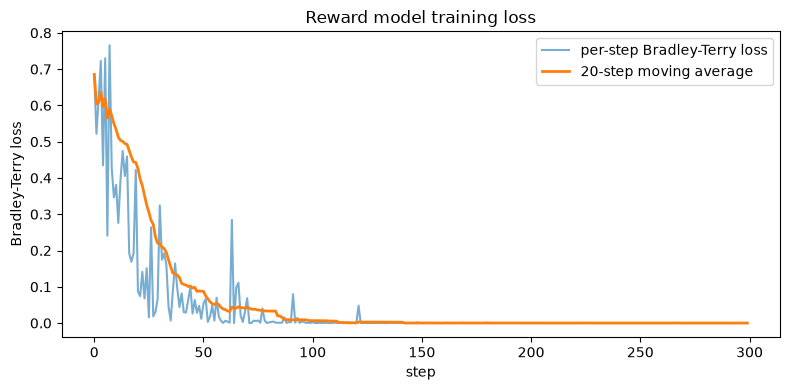

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(rm_losses, alpha=0.6, label="per-step Bradley-Terry loss")
window = 20
smoothed = [sum(rm_losses[max(0,i-window):i+1]) / len(rm_losses[max(0,i-window):i+1]) for i in range(len(rm_losses))]
plt.plot(smoothed, label=f"{window}-step moving average", linewidth=2)
plt.xlabel("step"); plt.ylabel("Bradley-Terry loss"); plt.title("Reward model training loss")
plt.legend(); plt.tight_layout(); plt.show()

In [12]:
# TEST 4: held-out ranking accuracy
reward_model.eval()
with torch.no_grad():
    ho_chosen = [encode_pair_text(p['prompt'], p['chosen'], BLOCK_SIZE) for p in held_out_pairs]
    ho_rejected = [encode_pair_text(p['prompt'], p['rejected'], BLOCK_SIZE) for p in held_out_pairs]
    ho_chosen_ids = torch.stack([c[0] for c in ho_chosen]).to(device)
    ho_chosen_lens = torch.tensor([c[1] for c in ho_chosen], device=device)
    ho_rejected_ids = torch.stack([r[0] for r in ho_rejected]).to(device)
    ho_rejected_lens = torch.tensor([r[1] for r in ho_rejected], device=device)
    r_chosen = reward_model(ho_chosen_ids, ho_chosen_lens)
    r_rejected = reward_model(ho_rejected_ids, ho_rejected_lens)
ranking_acc = (r_chosen > r_rejected).float().mean().item()
print(f"held-out ranking accuracy: {ranking_acc:.3f}")
assert ranking_acc > 0.6, f"ranking accuracy {ranking_acc:.3f} not above chance+margin (0.6)"
print("TEST 4 PASSED — reward model ranks held-out chosen > rejected well above chance")
reward_model.train()

# Freeze the reward model — it is used read-only from here on (PPO's terminal reward).
reward_model.eval()
for p in reward_model.parameters():
    p.requires_grad_(False)

held-out ranking accuracy: 1.000
TEST 4 PASSED — reward model ranks held-out chosen > rejected well above chance


### Question 2

TEST 4's ranking accuracy measures whether the reward model agrees with the *sentiment
classifier's* ranking on held-out pairs — not whether it agrees with a human's judgment of
story quality (Question 1). Given that, what would rising PPO reward (Part 4) actually
demonstrate — that the policy is producing "better stories", or something narrower? What
additional evidence (beyond the reward number) would you want before concluding PPO
"worked"?

*Write your answer below:*

---
## Part 3: PPO Core

Implements the pieces from `docs/llm_training_pipeline_reference.html#s6`: an actor-critic
wrapper around the policy (adds a value head without modifying `GPTModel`), rollout
generation that records both the policy's and a frozen reference model's log-probabilities
at each sampled token, GAE, and the clipped surrogate objective. Every piece is tested
against a hand-computed toy example before being used in the training loop (Part 4).

In [13]:
class PPOActorCritic(nn.Module):
    """Wraps a GPTModel, exposing both LM logits and a per-position scalar value
    estimate. Reuses the wrapped model's tok_emb/pos_emb/drop/blocks/ln_f/lm_head
    directly — no changes to src/llm_pipeline/model.py."""
    def __init__(self, gpt: GPTModel):
        super().__init__()
        self.gpt = gpt
        self.value_head = nn.Linear(gpt.config.n_embd, 1, bias=False)
        nn.init.normal_(self.value_head.weight, mean=0.0, std=0.02)

    def forward(self, idx):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device).unsqueeze(0)
        x = self.gpt.tok_emb(idx) + self.gpt.pos_emb(pos)
        x = self.gpt.drop(x)
        for block in self.gpt.blocks:
            x = block(x)
        x = self.gpt.ln_f(x)
        logits = self.gpt.lm_head(x)
        values = self.value_head(x).squeeze(-1)  # (B, T)
        return logits, values

In [14]:
@torch.no_grad()
def generate_rollout(actor_critic, ref_model, prompt_ids, max_new_tokens, temperature, top_k, block_size):
    """Samples max_new_tokens autoregressively from actor_critic, recording the
    policy's log-prob, the frozen ref_model's log-prob, and the value estimate at
    each sampled token. Returns (idx, policy_logprobs, ref_logprobs, values), each
    of shape (B, max_new_tokens) except idx which is (B, prompt_len + max_new_tokens)."""
    idx = prompt_ids.clone()
    policy_logprobs, ref_logprobs, values = [], [], []
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -block_size:]
        logits, vals = actor_critic(idx_cond)
        logits_last = logits[:, -1, :] / temperature
        if top_k is not None:
            v, _ = torch.topk(logits_last, top_k)
            logits_last[logits_last < v[:, [-1]]] = float("-inf")
        probs = F.softmax(logits_last, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        policy_lp = F.log_softmax(logits_last, dim=-1).gather(1, next_id).squeeze(-1)

        ref_logits, _ = ref_model(idx_cond)
        ref_lp = F.log_softmax(ref_logits[:, -1, :], dim=-1).gather(1, next_id).squeeze(-1)

        idx = torch.cat([idx, next_id], dim=1)
        policy_logprobs.append(policy_lp)
        ref_logprobs.append(ref_lp)
        values.append(vals[:, -1])
    return (
        idx,
        torch.stack(policy_logprobs, dim=1),
        torch.stack(ref_logprobs, dim=1),
        torch.stack(values, dim=1),
    )


def compute_token_rewards(policy_logprobs, ref_logprobs, terminal_reward, kl_beta):
    """Per-token reward = -kl_beta * KL at every step, plus terminal_reward added
    only at the last generated token (the reward model scores whole completions).
    Returns (rewards, kl), both (B, T)."""
    kl = policy_logprobs - ref_logprobs
    rewards = -kl_beta * kl
    rewards = rewards.clone()
    rewards[:, -1] = rewards[:, -1] + terminal_reward
    return rewards, kl


def compute_gae(rewards, values, gamma=1.0, lam=0.95):
    """rewards, values: (B, T). Returns (advantages, returns), both (B, T).
    Bootstraps with a next_value of 0 beyond the last generated token (episode end)."""
    B, T = rewards.shape
    advantages = torch.zeros_like(rewards)
    last_gae = torch.zeros(B, device=rewards.device)
    next_value = torch.zeros(B, device=rewards.device)
    for t in reversed(range(T)):
        delta = rewards[:, t] + gamma * next_value - values[:, t]
        last_gae = delta + gamma * lam * last_gae
        advantages[:, t] = last_gae
        next_value = values[:, t]
    returns = advantages + values
    return advantages, returns


def ppo_clipped_loss(new_logprobs, old_logprobs, advantages, clip_eps=0.2):
    ratio = torch.exp(new_logprobs - old_logprobs)
    unclipped = ratio * advantages
    clipped = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * advantages
    return -torch.min(unclipped, clipped).mean()


def evaluate_actions(policy, idx, prompt_len, gen_len):
    """Re-runs the (now-updated) policy over the full generated sequence and
    extracts log-probs and values at exactly the positions/tokens that were
    sampled during the rollout. Returns (logprobs, values), both (B, gen_len)."""
    logits, values = policy(idx[:, :-1])
    action_logits = logits[:, prompt_len - 1 : prompt_len - 1 + gen_len, :]
    action_values = values[:, prompt_len - 1 : prompt_len - 1 + gen_len]
    actions = idx[:, prompt_len : prompt_len + gen_len]
    logprobs = F.log_softmax(action_logits, dim=-1).gather(-1, actions.unsqueeze(-1)).squeeze(-1)
    return logprobs, action_values

In [15]:
# TEST 5: GAE against a hand-computed toy trajectory (gamma=1, lambda=1 -> Monte Carlo advantage)
rewards = torch.tensor([[1.0, 0.0, 2.0]])
values = torch.tensor([[0.5, 0.5, 0.5]])
adv, ret = compute_gae(rewards, values, gamma=1.0, lam=1.0)
# hand derivation: return_t = sum of rewards from t onward; advantage_t = return_t - value_t
# return_2 = 2.0 -> adv_2 = 2.0 - 0.5 = 1.5
# return_1 = 0.0 + 2.0 = 2.0 -> adv_1 = 2.0 - 0.5 = 1.5
# return_0 = 1.0 + 0.0 + 2.0 = 3.0 -> adv_0 = 3.0 - 0.5 = 2.5
expected_adv = torch.tensor([[2.5, 1.5, 1.5]])
expected_ret = torch.tensor([[3.0, 2.0, 2.0]])
assert torch.allclose(adv, expected_adv, atol=1e-5), f"{adv} != {expected_adv}"
assert torch.allclose(ret, expected_ret, atol=1e-5), f"{ret} != {expected_ret}"
print("TEST 5 PASSED — GAE matches hand-computed toy trajectory")

TEST 5 PASSED — GAE matches hand-computed toy trajectory


In [16]:
# TEST 6: clipped surrogate objective at the clip boundary (both advantage signs)
clip_eps = 0.2
old_lp = torch.tensor([0.0, 0.0])

new_lp_high = torch.log(torch.tensor([1.3, 1.3]))  # ratio = 1.3 -> clipped to 1.2
adv_pos = torch.tensor([1.0, 1.0])
loss_pos = ppo_clipped_loss(new_lp_high, old_lp, adv_pos, clip_eps)
# unclipped = 1.3*1 = 1.3, clipped = 1.2*1 = 1.2, min = 1.2, loss = -1.2
assert abs(loss_pos.item() - (-1.2)) < 1e-4, f"expected -1.2, got {loss_pos.item()}"
print(f"TEST 6a PASSED — positive-advantage clip boundary uses the clipped (pessimistic) term: loss={loss_pos.item():.4f}")

new_lp_low = torch.log(torch.tensor([0.7, 0.7]))  # ratio = 0.7 -> clipped to 0.8
adv_neg = torch.tensor([-1.0, -1.0])
loss_neg = ppo_clipped_loss(new_lp_low, old_lp, adv_neg, clip_eps)
# unclipped = 0.7*-1 = -0.7, clipped = 0.8*-1 = -0.8, min(-0.7,-0.8) = -0.8, loss = 0.8
assert abs(loss_neg.item() - 0.8) < 1e-4, f"expected 0.8, got {loss_neg.item()}"
print(f"TEST 6b PASSED — negative-advantage clip boundary uses the clipped (pessimistic) term: loss={loss_neg.item():.4f}")

# Sanity: an unclipped ratio (inside [0.8, 1.2]) must equal ratio * advantage exactly.
new_lp_mid = torch.log(torch.tensor([1.05, 1.05]))
loss_mid = ppo_clipped_loss(new_lp_mid, old_lp, adv_pos, clip_eps)
assert abs(loss_mid.item() - (-1.05)) < 1e-4, f"expected -1.05, got {loss_mid.item()}"
print(f"TEST 6c PASSED — ratio inside the clip range is left unclipped: loss={loss_mid.item():.4f}")

TEST 6a PASSED — positive-advantage clip boundary uses the clipped (pessimistic) term: loss=-1.2000
TEST 6b PASSED — negative-advantage clip boundary uses the clipped (pessimistic) term: loss=0.8000
TEST 6c PASSED — ratio inside the clip range is left unclipped: loss=-1.0500


### Question 3

`compute_token_rewards` adds the reward model's terminal score only at the *last*
generated token, while the KL penalty is subtracted at *every* token. If a completion is
very long, the cumulative KL penalty (summed via the recursive GAE backup) can end up
comparable in magnitude to the one-time terminal reward. What effect would you expect this
to have on a PPO run with an unusually large `max_new_tokens`, and why does that argue for
keeping completions short in this pipeline's setting?

*Write your answer below:*